 Object Type         | Description                                                           
 ------------------- | --------------------------------------------------------------------- 
 `Team`              | The team associated with the event.                                   
 `Player`              | The player in possession of the ball or associated with the event.       
 `Possession` | Unique ID for each case--an attack. 'AA' indicates away team attack, 'HA' indicates home team attack    
 `end_grid`          | The grid zone where the event ends.                              
 ------------------- | --------------------------------------------------------------------- 
 **Attribute**                      | **Description**                                               
 `attribute:subtype`            | Event subtype (e.g. `"PASS"`, `"GOAL"`, `"SHOT"`). For details please refer to the data documentation.     
 `attribute:start_x`, `start_y` | X/Y coordinates of the ball at the start of the event.        
 `attribute:end_x`, `end_y`     | X/Y coordinates of the ball at the end of the event.          
 `attribute:duration`           | Duration (in seconds) of the event.                           
 `attribute:travel_distance`    | Distance traveled by the ball.                                
 `attribute:start_grid`         | Grid ID where the event begins.                               
 `attribute:crossed_grid`       | If the event start in one grid and ends in another.           
 `attribute:attack_game`        | Identifier for attack sequence. Combined count of both team. 
 `attribute:attack_successful`  | Boolean flag — `True` if the attack led to a goal.            
 `attribute:home_team_score`    | Cumulative score of the home team at this point in the match.
 `attribute:away_team_score`    | Cumulative score of the away team at this point in the match. 


In [ ]:
import pandas as pd
import pm4py
from Soccer_ocel import soccer_ocel_df
import numpy as np
from filters_and_analysis import movement_frequency_report

In [2]:
# settings
## Resolution of the grid
x_fields = 6
y_fields = 4

df = pd.read_csv('sample-data\data\Sample_Game_1\Sample_Game_1_RawEventsData.csv')
tracking_data_away_df = pd.read_csv('sample-data\data\Sample_Game_1\Sample_Game_1_RawTrackingData_Away_Team.csv', skiprows=2)
tracking_data_home_df = pd.read_csv('sample-data\data\Sample_Game_1\Sample_Game_1_RawTrackingData_Home_Team.csv', skiprows=2)

ocel_df = soccer_ocel_df(df, tracking_data_home_df, tracking_data_away_df, x_fields=x_fields, y_fields=y_fields)

c:\Users\Vito\Documents\pm\Soccer\Soccer_ocel.py:199: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_change_events.rename(columns={'Grid Position': 'To Position',


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
ocel_df[(ocel_df['case:concept:name']=='AA156') & (ocel_df['concept:name']!='Player changes position')]#156

,Team,concept:name,attribute:subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],Player,attribute:start_x,attribute:start_y,attribute:end_x,attribute:end_y,time:timestamp,attribute:duration,attribute:travel_distance,attribute:start_grid,end_grid,attribute:crossed_grid,attribute:attack_game,case:concept:name,attribute:attack_successful,attribute:home_team_score,attribute:away_team_score,ball,Time [s],Frame,crossed_grid,Possession
15896,Away,RECOVERY,INTERCEPTION,2.0,124197.0,4967.88,124197.0,4967.88,Player15,0.31,0.51,NaN,NaN,1970-01-01 01:22:47.880,0.00,NaN,B3,None,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15897,Away,PASS Out,NaN,2.0,124219.0,4968.76,124259.0,4970.36,Player15,0.32,0.53,0.27,0.78,1970-01-01 01:22:48.760,1.60,0.254951,B3,B4,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15901,Away,PASS Received,NaN,2.0,124219.0,4968.76,124259.0,4970.36,Player17,0.27,0.78,0.27,0.78,1970-01-01 01:22:50.360,1.60,0.254951,B4,B4,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15913,Away,PASS Out,NaN,2.0,124324.0,4972.96,124356.0,4974.24,Player17,0.23,0.75,0.26,0.52,1970-01-01 01:22:52.960,1.28,0.231948,B4,B3,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15915,Away,PASS Received,NaN,2.0,124324.0,4972.96,124356.0,4974.24,Player16,0.26,0.52,0.26,0.52,1970-01-01 01:22:54.240,1.28,0.231948,B3,B3,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15921,Away,PASS Out,NaN,2.0,124396.0,4975.84,124451.0,4978.04,Player16,0.27,0.51,0.50,0.07,1970-01-01 01:22:55.840,2.20,0.496488,B3,D1,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15930,Away,PASS Received,NaN,2.0,124396.0,4975.84,124451.0,4978.04,Player27,0.50,0.07,0.50,0.07,1970-01-01 01:22:58.040,2.20,0.496488,D1,D1,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15943,Away,PASS Out,NaN,2.0,124504.0,4980.16,124514.0,4980.56,Player27,0.55,0.07,0.59,0.22,1970-01-01 01:23:00.160,0.40,0.155242,D1,D1,False,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15945,Away,PASS Received,NaN,2.0,124504.0,4980.16,124514.0,4980.56,Player28,0.59,0.22,0.59,0.22,1970-01-01 01:23:00.560,0.40,0.155242,D1,D1,False,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156
15949,Away,PASS Out,NaN,2.0,124536.0,4981.44,124614.0,4984.56,Player28,0.60,0.21,0.81,0.04,1970-01-01 01:23:01.440,3.12,0.270185,D1,E1,True,319,AA156,False,4,0,ball_1,NaN,NaN,NaN,AA156


In [54]:
def get_player_trajectory(df, player_col_name):

    x_idx = df.columns.get_loc(player_col_name)
    
    y_idx = x_idx + 1
    y_col_name = df.columns[y_idx]

    time_points = df['Time [s]'].values

    x_coords = df[player_col_name].values
    y_coords = df[y_col_name].values

    mask = (~pd.isnull(x_coords)) & (~pd.isnull(y_coords))
    time_points = time_points[mask]
    x_coords = x_coords[mask]
    y_coords = y_coords[mask]

    return time_points, x_coords, y_coords
def calculate_zone_fractions(x_coords, team):
    if team == 'Away':
        # Attacking direction is right (increasing x)
        defense_zone = (0.0, 0.5)
        #midfield_zone = (0.5, 0.75)
        attack_zone = (0.5, 1.0)
    else:  # Home team attacks left
        defense_zone = (0.5, 1.0)
        #midfield_zone = (0.25, 0.5)
        attack_zone = (0.0, 0.5)

    total = len(x_coords)
    if total == 0:
        return 0, 0, 0

    defense_frac = ((x_coords >= defense_zone[0]) & (x_coords < defense_zone[1])).sum() / total
    #midfield_frac = ((x_coords >= midfield_zone[0]) & (x_coords < midfield_zone[1])).sum() / total
    attack_frac  = ((x_coords >= attack_zone[0])  & (x_coords < attack_zone[1])).sum() / total

    return defense_frac, attack_frac
def classify_all_players(tracking_df, team_name):
    def_L=[]
    att_L=[]
    for col in tracking_df.columns:
        if col.startswith("Player"):
            _,x, y = get_player_trajectory(tracking_df, col)
            def_frac, att_frac = calculate_zone_fractions(x, team_name)
            role = np.argmax([def_frac, att_frac])
            if role==0:
                def_L.append(col)
            else:
                att_L.append(col)

    return def_L, att_L
away_def,away_att = classify_all_players(tracking_data_away_df, 'Away')
home_def,home_att = classify_all_players(tracking_data_home_df, 'Home')
att_players=away_att+home_att
def_players=away_def+home_def
print(att_players)
print(def_players)


['Player15', 'Player16', 'Player17', 'Player18', 'Player19', 'Player21', 'Player22', 'Player23', 'Player26', 'Player27', 'Player28', 'Player1', 'Player13', 'Player14']
['Player25', 'Player20', 'Player24', 'Player11', 'Player2', 'Player3', 'Player4', 'Player5', 'Player6', 'Player7', 'Player8', 'Player9', 'Player10', 'Player12']


In [51]:
goalkeepers=[]
col_L,frac_L=[],[]
for col in tracking_data_away_df.columns:
    if col.startswith("Player"):
        _,x_trace,y_trace=get_player_trajectory(tracking_data_away_df,col)
        frac=fraction_time_in_goal_area(x_trace,y_trace, 'Away')
        col_L.append(col)
        frac_L.append(frac)
goalkeepers.append(col_L[np.argmax(frac)])
col_L,frac_L=[],[]
for col in tracking_data_home_df.columns:
    if col.startswith("Player"):
        _,x_trace,y_trace=get_player_trajectory(tracking_data_home_df,col)
        frac=fraction_time_in_goal_area(x_trace,y_trace, 'Home')
        col_L.append(col)
        frac_L.append(frac)
goalkeepers.append(col_L[np.argmax(frac)])

0.16325531357323145
0.033495165717280666
0.012764989034936485
0.014971794270581908
0.0022068052356454216
0.0040207403188112015
0.03579162241562418
0.016178640883825497
0.008262452161056996
0.006944540225921686
0.020056473325265715
0.011325765465528015
0.0025433950390686454
0.0
0.13595299504848074
0.004260694557444439
0.003599851040646594
0.0061307807952774365
0.0027654028109181687
0.008385859895452602
0.0035994911997401873
0.0017723404548777293
0.008420341227259561
0.009047901466146228
0.0005354553842098326
0.0001424197108879869
0.0
0.0


In [ ]:
att_players = [p for p in att_players if p not in goalkeepers]
def_players = [p for p in def_players if p not in goalkeepers]

14
14
14
12


In [58]:
ocel_df['Goalkeeper'] = np.nan
ocel_df['Attacker'] = np.nan
ocel_df['Defender'] = np.nan

ocel_df.loc[ocel_df['Player'].isin(att_players), 'Attacker'] = ocel_df['Player']
ocel_df.loc[ocel_df['Player'].isin(goalkeepers), 'Goalkeeper'] = ocel_df['Player']
ocel_df.loc[ocel_df['Player'].isin(def_players), 'Defender'] = ocel_df['Player']

C:\Users\Vito\AppData\Local\Temp\ipykernel_20512\2618469596.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Player19' 'Player19' 'Player15' ... 'Player23' 'Player23' 'Player13']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ocel_df.loc[ocel_df['Player'].isin(att_players), 'Attacker'] = ocel_df['Player']
C:\Users\Vito\AppData\Local\Temp\ipykernel_20512\2618469596.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Player25' 'Player11' 'Player25' 'Player25' 'Player11' 'Player11'
 'Player25' 'Player25' 'Player25' 'Player25' 'Player25' 'Player11'
 'Player25' 'Player11' 'Player25' 'Player25' 'Player11' 'Player25'
 'Player11' 'Player25' 'Player11' 'Player25' 'Player25' 'Player11'
 'Player25' 'Player25' 'Player25' 'Player11' 'Player25' 'Player25'
 'Player11' 'Player25' 'Player

In [70]:
from Soccer_ocel import soccer_df_to_ocel
from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
def soccer_df_to_ocel_mod(df):
    #df = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='Activity', timestamp_key='Timestamp')
    event_log = pm4py.convert_to_event_log(df)

    # convert to ocel
    ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                         , timestamp_column='time:timestamp'
                                         , obj_types=['ball','Goalkeeper','Attacker','Defender']
                                         ,additional_event_attributes=['attribute:subtype','Team','end_grid','case:concept:name'
                                                                       , 'attribute:start_x', 'attribute:start_y'
                                                                       , 'attribute:end_x', 'attribute:end_y' 
                                                                       , 'attribute:duration', 'attribute:travel_distance'
                                                                       , 'attribute:start_grid', 'attribute:crossed_grid'
                                                                       , 'attribute:attack_game', 'attribute:attack_successful'
                                                                       , 'attribute:home_team_score', 'attribute:away_team_score'
                                                                       ])
    return ocel

In [71]:
ocel= soccer_df_to_ocel_mod(ocel_df)

In [5]:
pm4py.write_ocel(ocel, "output_logs/game1.xmlocel")

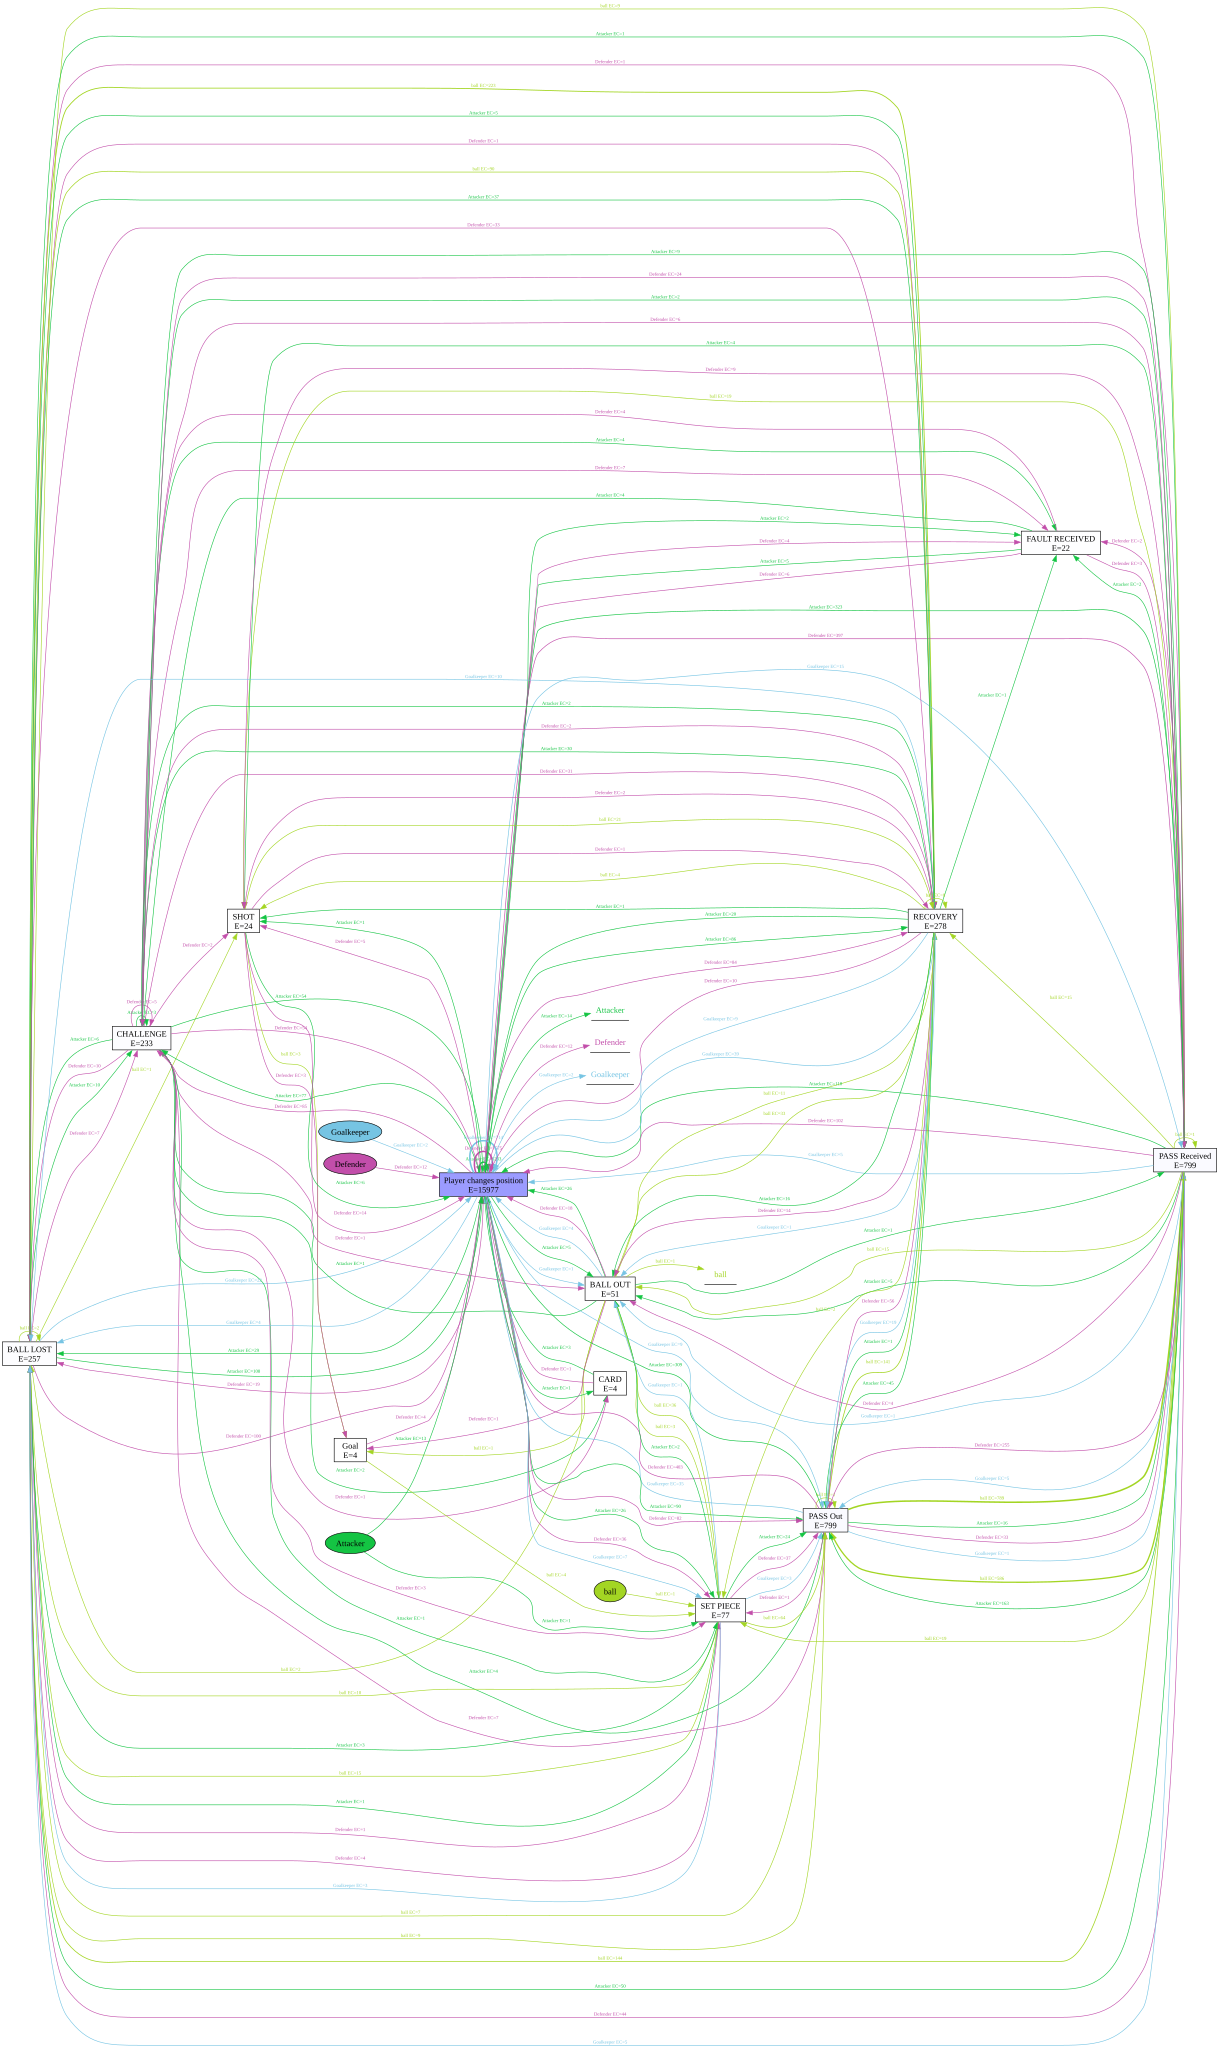

In [62]:
dfg=pm4py.ocel.discover_ocdfg(ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

In [ ]:
#split by team
Away_df=ocel_df[ocel_df['Team']=='Away']
Home_df=ocel_df[ocel_df['Team']=='Home']

In [58]:
aa_max = pd.Series(ocel_df['case:concept:name'].unique()).str.extract(r'^AA(\d+)$')[0].dropna().astype(int).max()
print('Away team made ',aa_max,' attacks')
ha_max = pd.Series(ocel_df['case:concept:name'].unique()).str.extract(r'^HA(\d+)$')[0].dropna().astype(int).max()
print('Home team made ',ha_max,' attacks')

Away team made  175  attacks
Home team made  180  attacks


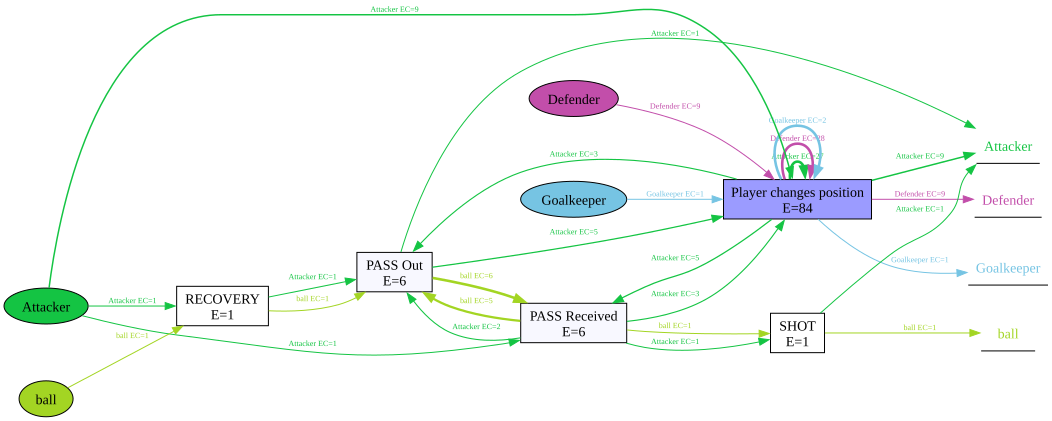

In [78]:
case_156=ocel_df[ocel_df['case:concept:name']=='AA156']
case_156_ocel=soccer_df_to_ocel_mod(case_156)
dfg=pm4py.ocel.discover_ocdfg(case_156_ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

In [72]:
#shot case
#All_shot_attacks=ocel_df[
#    ocel_df['concept:name'].str.startswith('SHOT') |
#    ocel_df['concept:name'].str.endswith('GOAL')]['case:concept:name'].unique()
#Goal_attack=ocel_df[ocel_df['concept:name'].str.endswith('GOAL')]['case:concept:name'].unique()

All_shot_attacks=ocel_df[
    ocel_df['concept:name'].str.startswith('SHOT') |
    ocel_df['attribute:subtype'].str.endswith('GOAL')]['case:concept:name'].unique()
Goal_attack = ocel_df[ocel_df['attribute:subtype'].str.endswith('GOAL', na=False)]['case:concept:name'].unique()

attack_df=ocel_df[ocel_df['case:concept:name'].isin(All_shot_attacks)]
Goal_attack_df=ocel_df[ocel_df['case:concept:name'].isin(Goal_attack)]
Failed_attack_df=ocel_df[ocel_df['case:concept:name'].isin(All_shot_attacks)&~ocel_df['case:concept:name'].isin(Goal_attack)]

In [65]:
#shot case last player only by team
def filter_by_last_player(df):
    relevant_events = df[
        df['concept:name'].str.startswith('SHOT') |
        df['concept:name'].str.endswith('GOAL')
    ].set_index('case:concept:name')['Player']
    
    # Step 3: Filter original DataFrame
    def include_row(row):
        if row['concept:name'] != 'Player changes position':
            return True
        last_player = relevant_events.get(row['case:concept:name'])
        return row['Player'] == last_player
    
    return df[df.apply(include_row, axis=1)]
def filter_by_involved_player(df):
    grouped = df.groupby('case:concept:name')

    def include_row(row):
        if row['concept:name'] != 'Player changes position':
            return True
        
        case_id = row['case:concept:name']
        player = row['Player']
        case_df = grouped.get_group(case_id)

        case_df_other = case_df[case_df['concept:name'] != 'Player changes position']

        involved = (case_df_other['Player'] == player)
        return involved.any()
    return df[df.apply(include_row, axis=1)]
last_player_attack_df=filter_by_last_player(attack_df)
last_player_goal_attack_df=filter_by_last_player(Goal_attack_df)
last_player_failed_attack_df=filter_by_last_player(Failed_attack_df)

#shot case all involved players by team
involved_player_attack_df=filter_by_involved_player(attack_df)
involved_player_goal_attack_df=filter_by_involved_player(Goal_attack_df)
involved_player_failed_attack_df=filter_by_involved_player(Failed_attack_df)

In [73]:
Goal_attack_ocel= soccer_df_to_ocel_mod(Goal_attack_df)
Failed_attack_ocel= soccer_df_to_ocel_mod(Failed_attack_df)
Failed_attack_ocel_home= soccer_df_to_ocel_mod(Failed_attack_df[Failed_attack_df['Team']=='Home'])
Failed_attack_ocel_away= soccer_df_to_ocel_mod(Failed_attack_df[Failed_attack_df['Team']=='Away'])

In [22]:
pm4py.write_ocel(Goal_attack_ocel, "output_logs/game1_goal.xmlocel")
pm4py.write_ocel(Failed_attack_ocel, "output_logs/game1_failed.xmlocel")
pm4py.write_ocel(Failed_attack_ocel_home, "output_logs/game1_failed_home.xmlocel")
pm4py.write_ocel(Failed_attack_ocel_away, "output_logs/game1_failed_away.xmlocel")

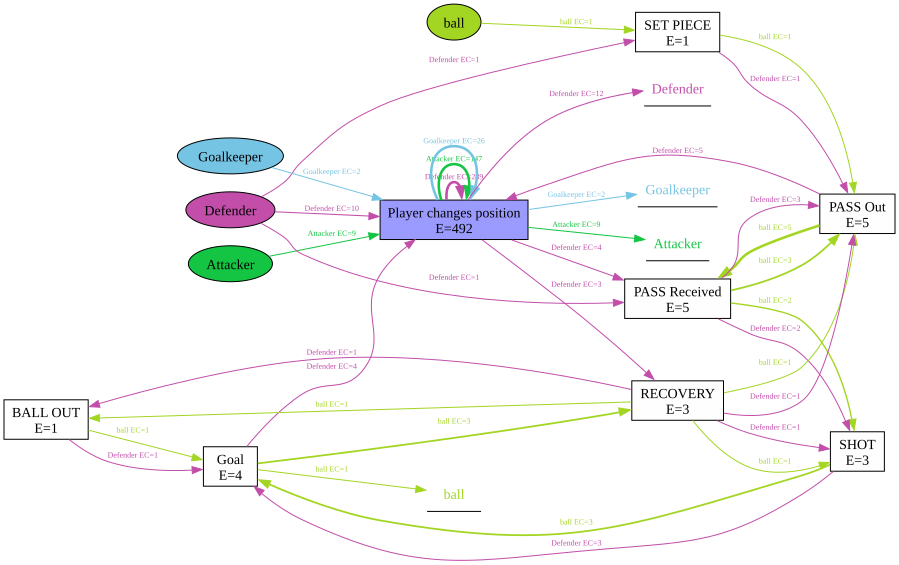

In [74]:
dfg=pm4py.ocel.discover_ocdfg(Goal_attack_ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

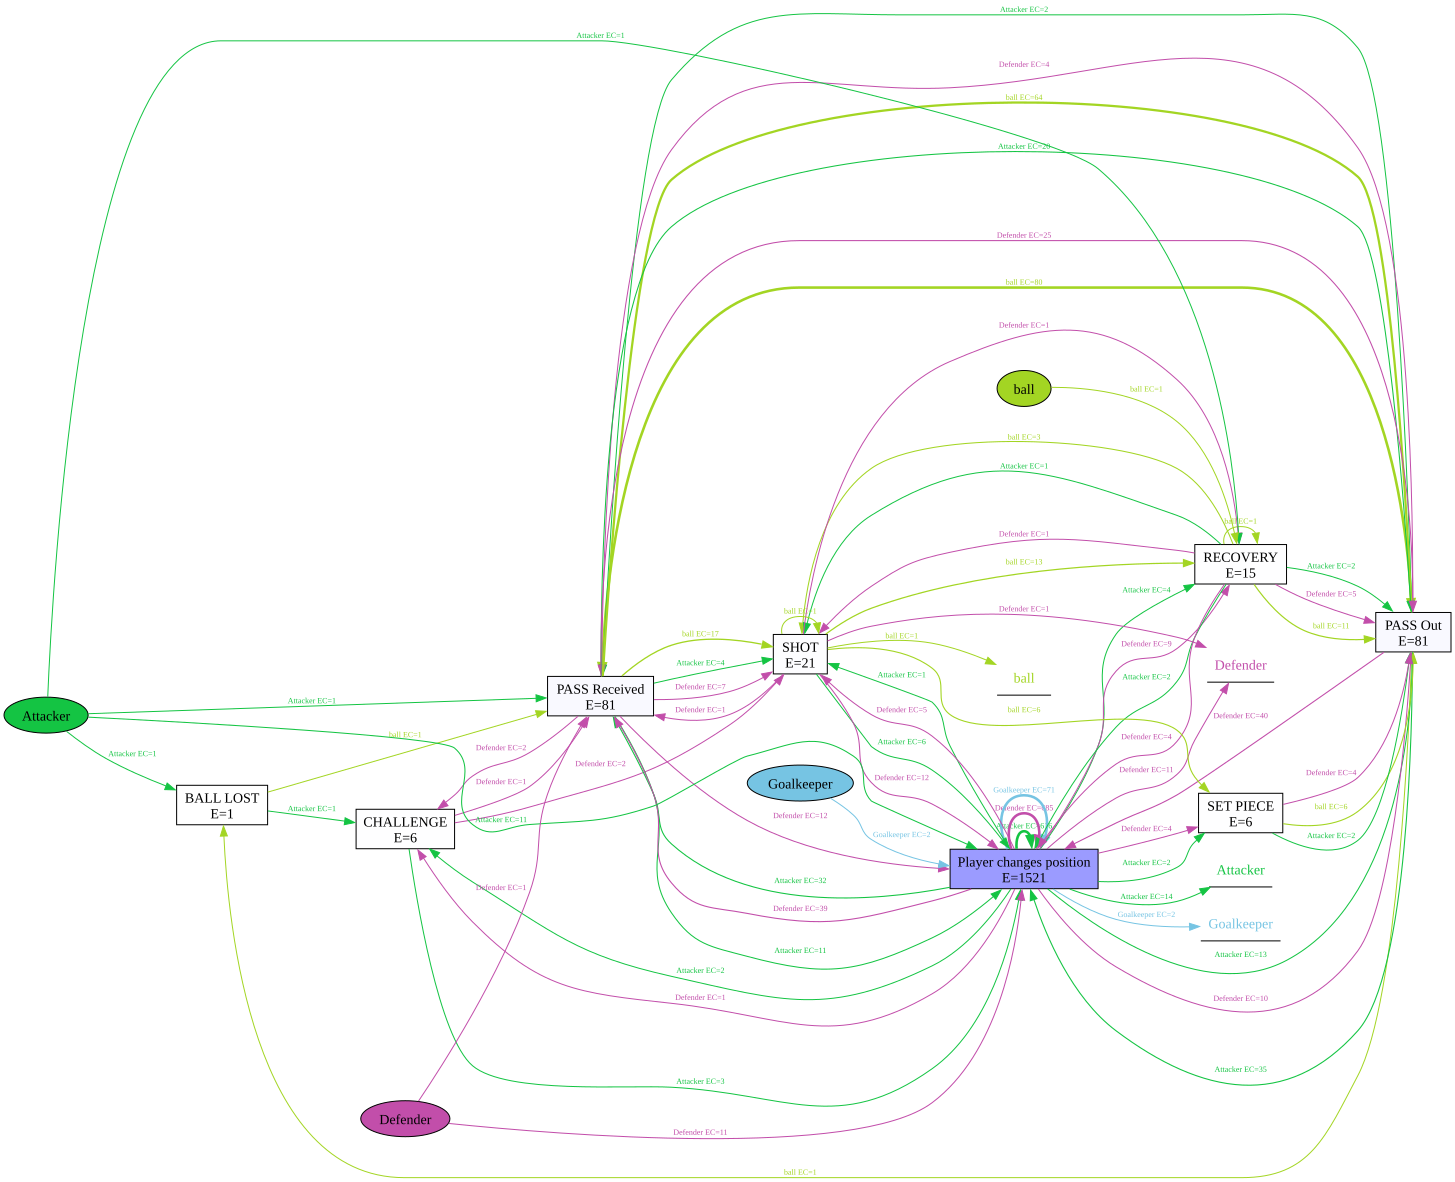

In [75]:
dfg=pm4py.ocel.discover_ocdfg(Failed_attack_ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

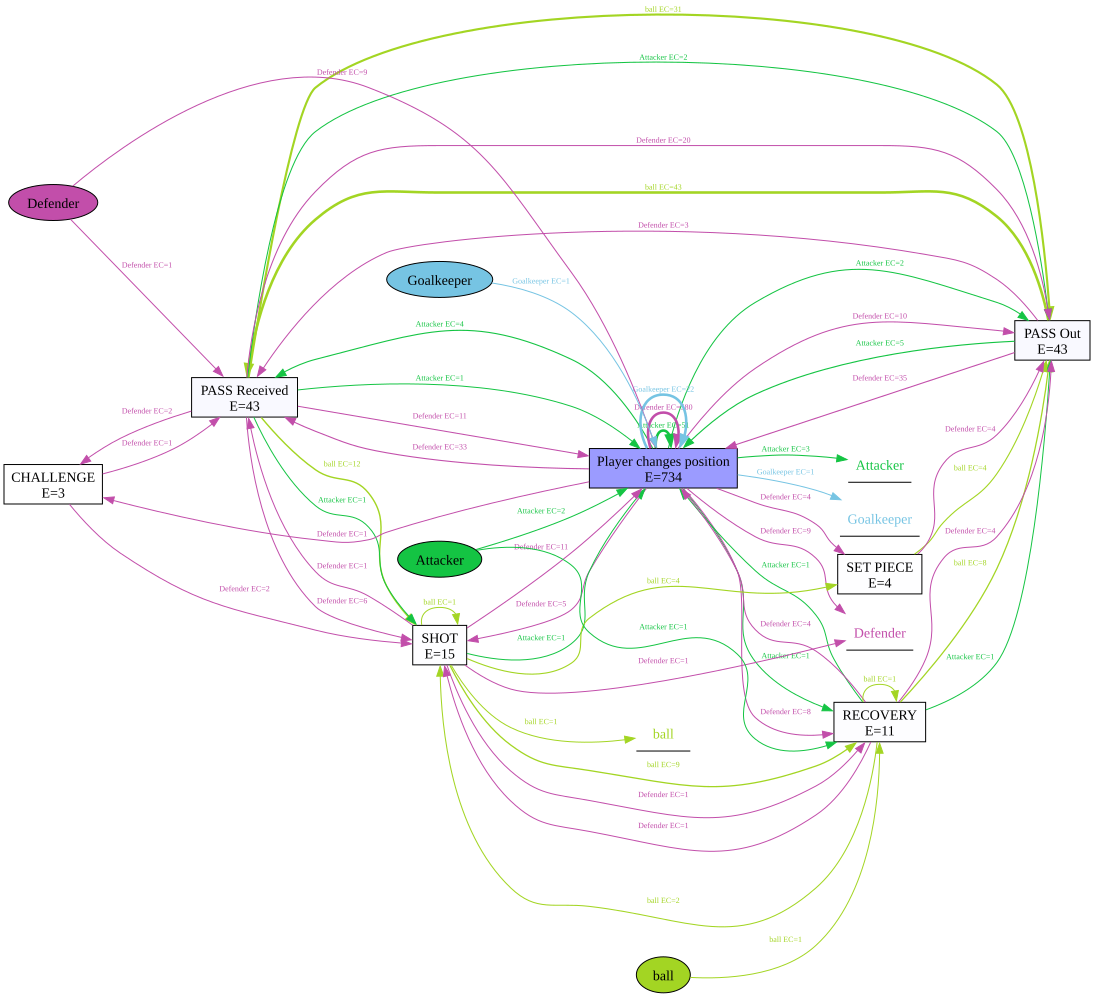

In [76]:
dfg=pm4py.ocel.discover_ocdfg(Failed_attack_ocel_home)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

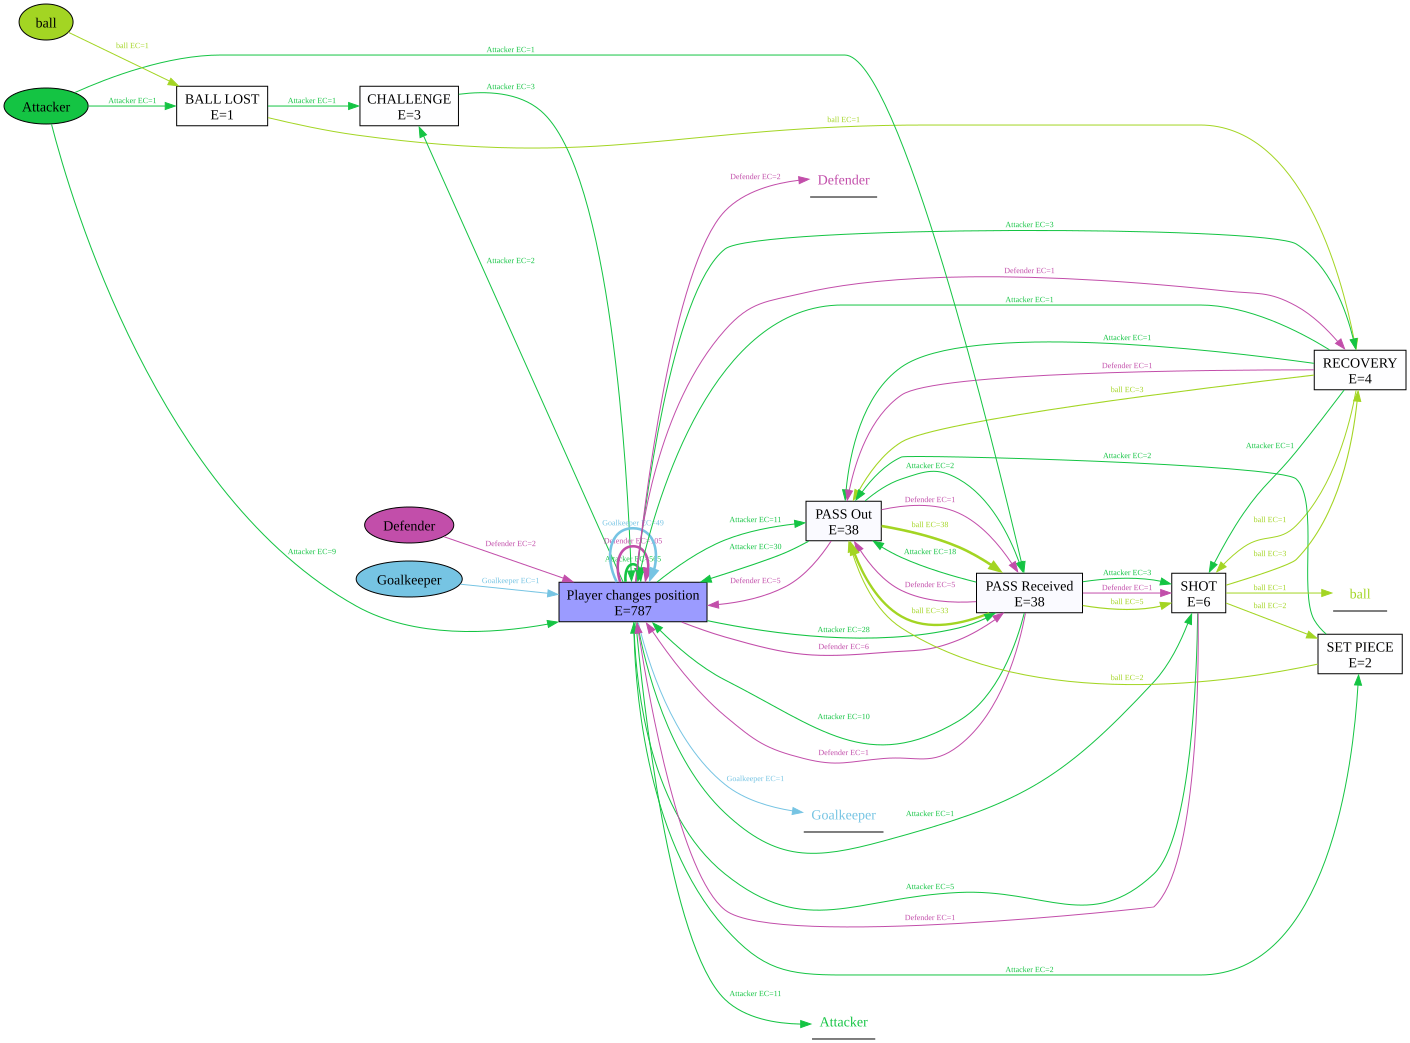

In [77]:
dfg=pm4py.ocel.discover_ocdfg(Failed_attack_ocel_away)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

In [18]:
#shot case last player only by team
#last_player_attack_df=filter_by_last_player(attack_df)
#last_player_goal_attack_df=filter_by_last_player(Goal_attack_df)
#last_player_failed_attack_df=filter_by_last_player(Failed_attack_df)

#shot case all involved players by team
involved_player_attack_df=filter_by_involved_player(attack_df)
involved_player_goal_attack_df=filter_by_involved_player(Goal_attack_df)
involved_player_failed_attack_df=filter_by_involved_player(Failed_attack_df)

In [19]:
involved_player_Goal_attack_ocel= soccer_df_to_ocel(involved_player_goal_attack_df)
involved_player_Failed_attack_ocel= soccer_df_to_ocel(involved_player_failed_attack_df)
involved_player_Failed_attack_ocel_home= soccer_df_to_ocel(involved_player_failed_attack_df[involved_player_failed_attack_df['Team']=='Home'])
involved_player_Failed_attack_ocel_away= soccer_df_to_ocel(involved_player_failed_attack_df[involved_player_failed_attack_df['Team']=='Away'])

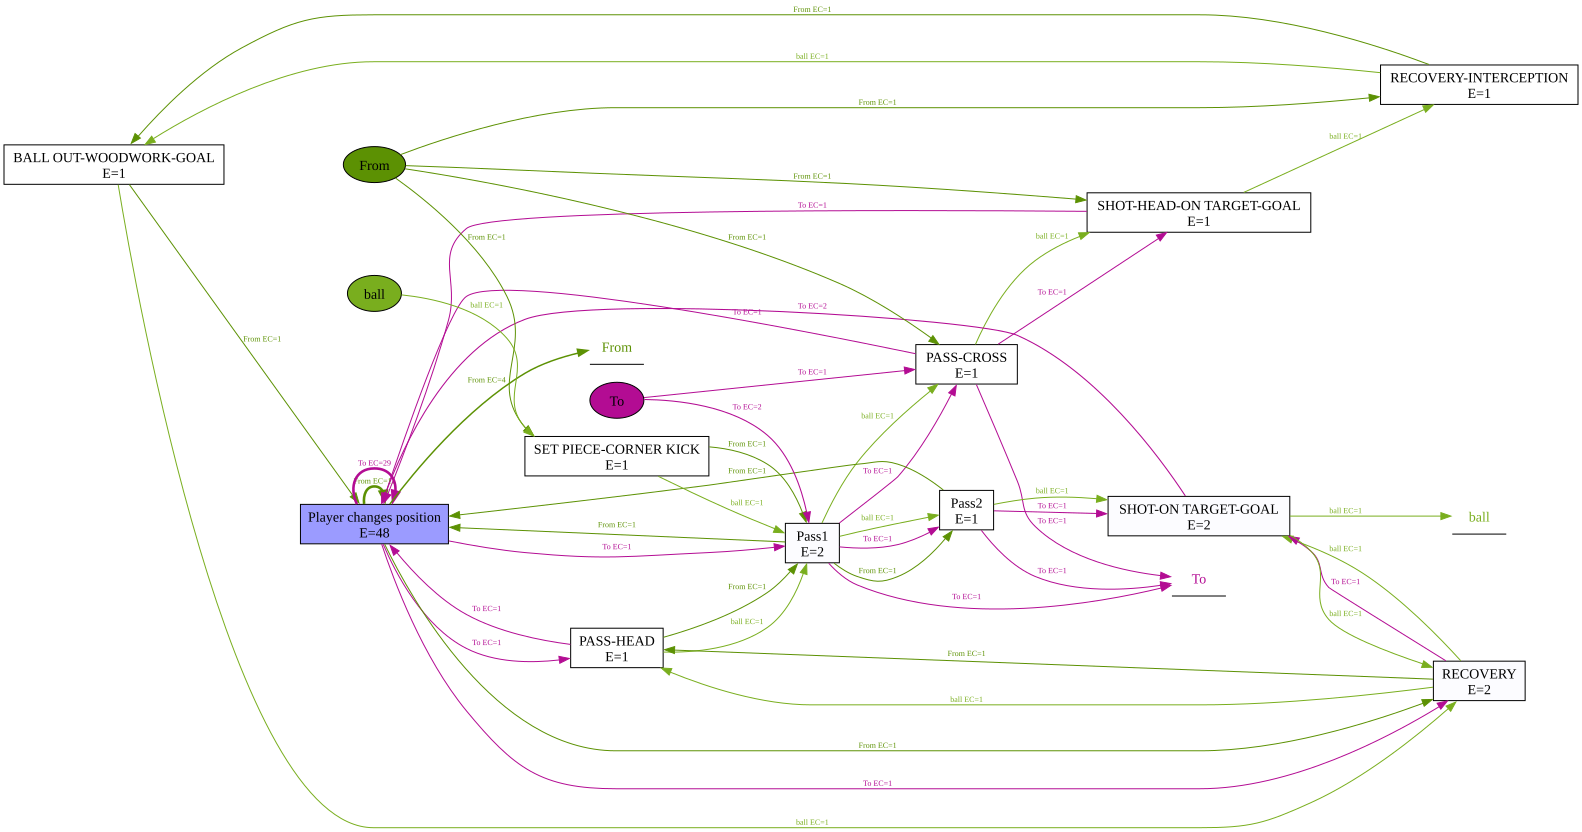

In [20]:
dfg=pm4py.ocel.discover_ocdfg(involved_player_Goal_attack_ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

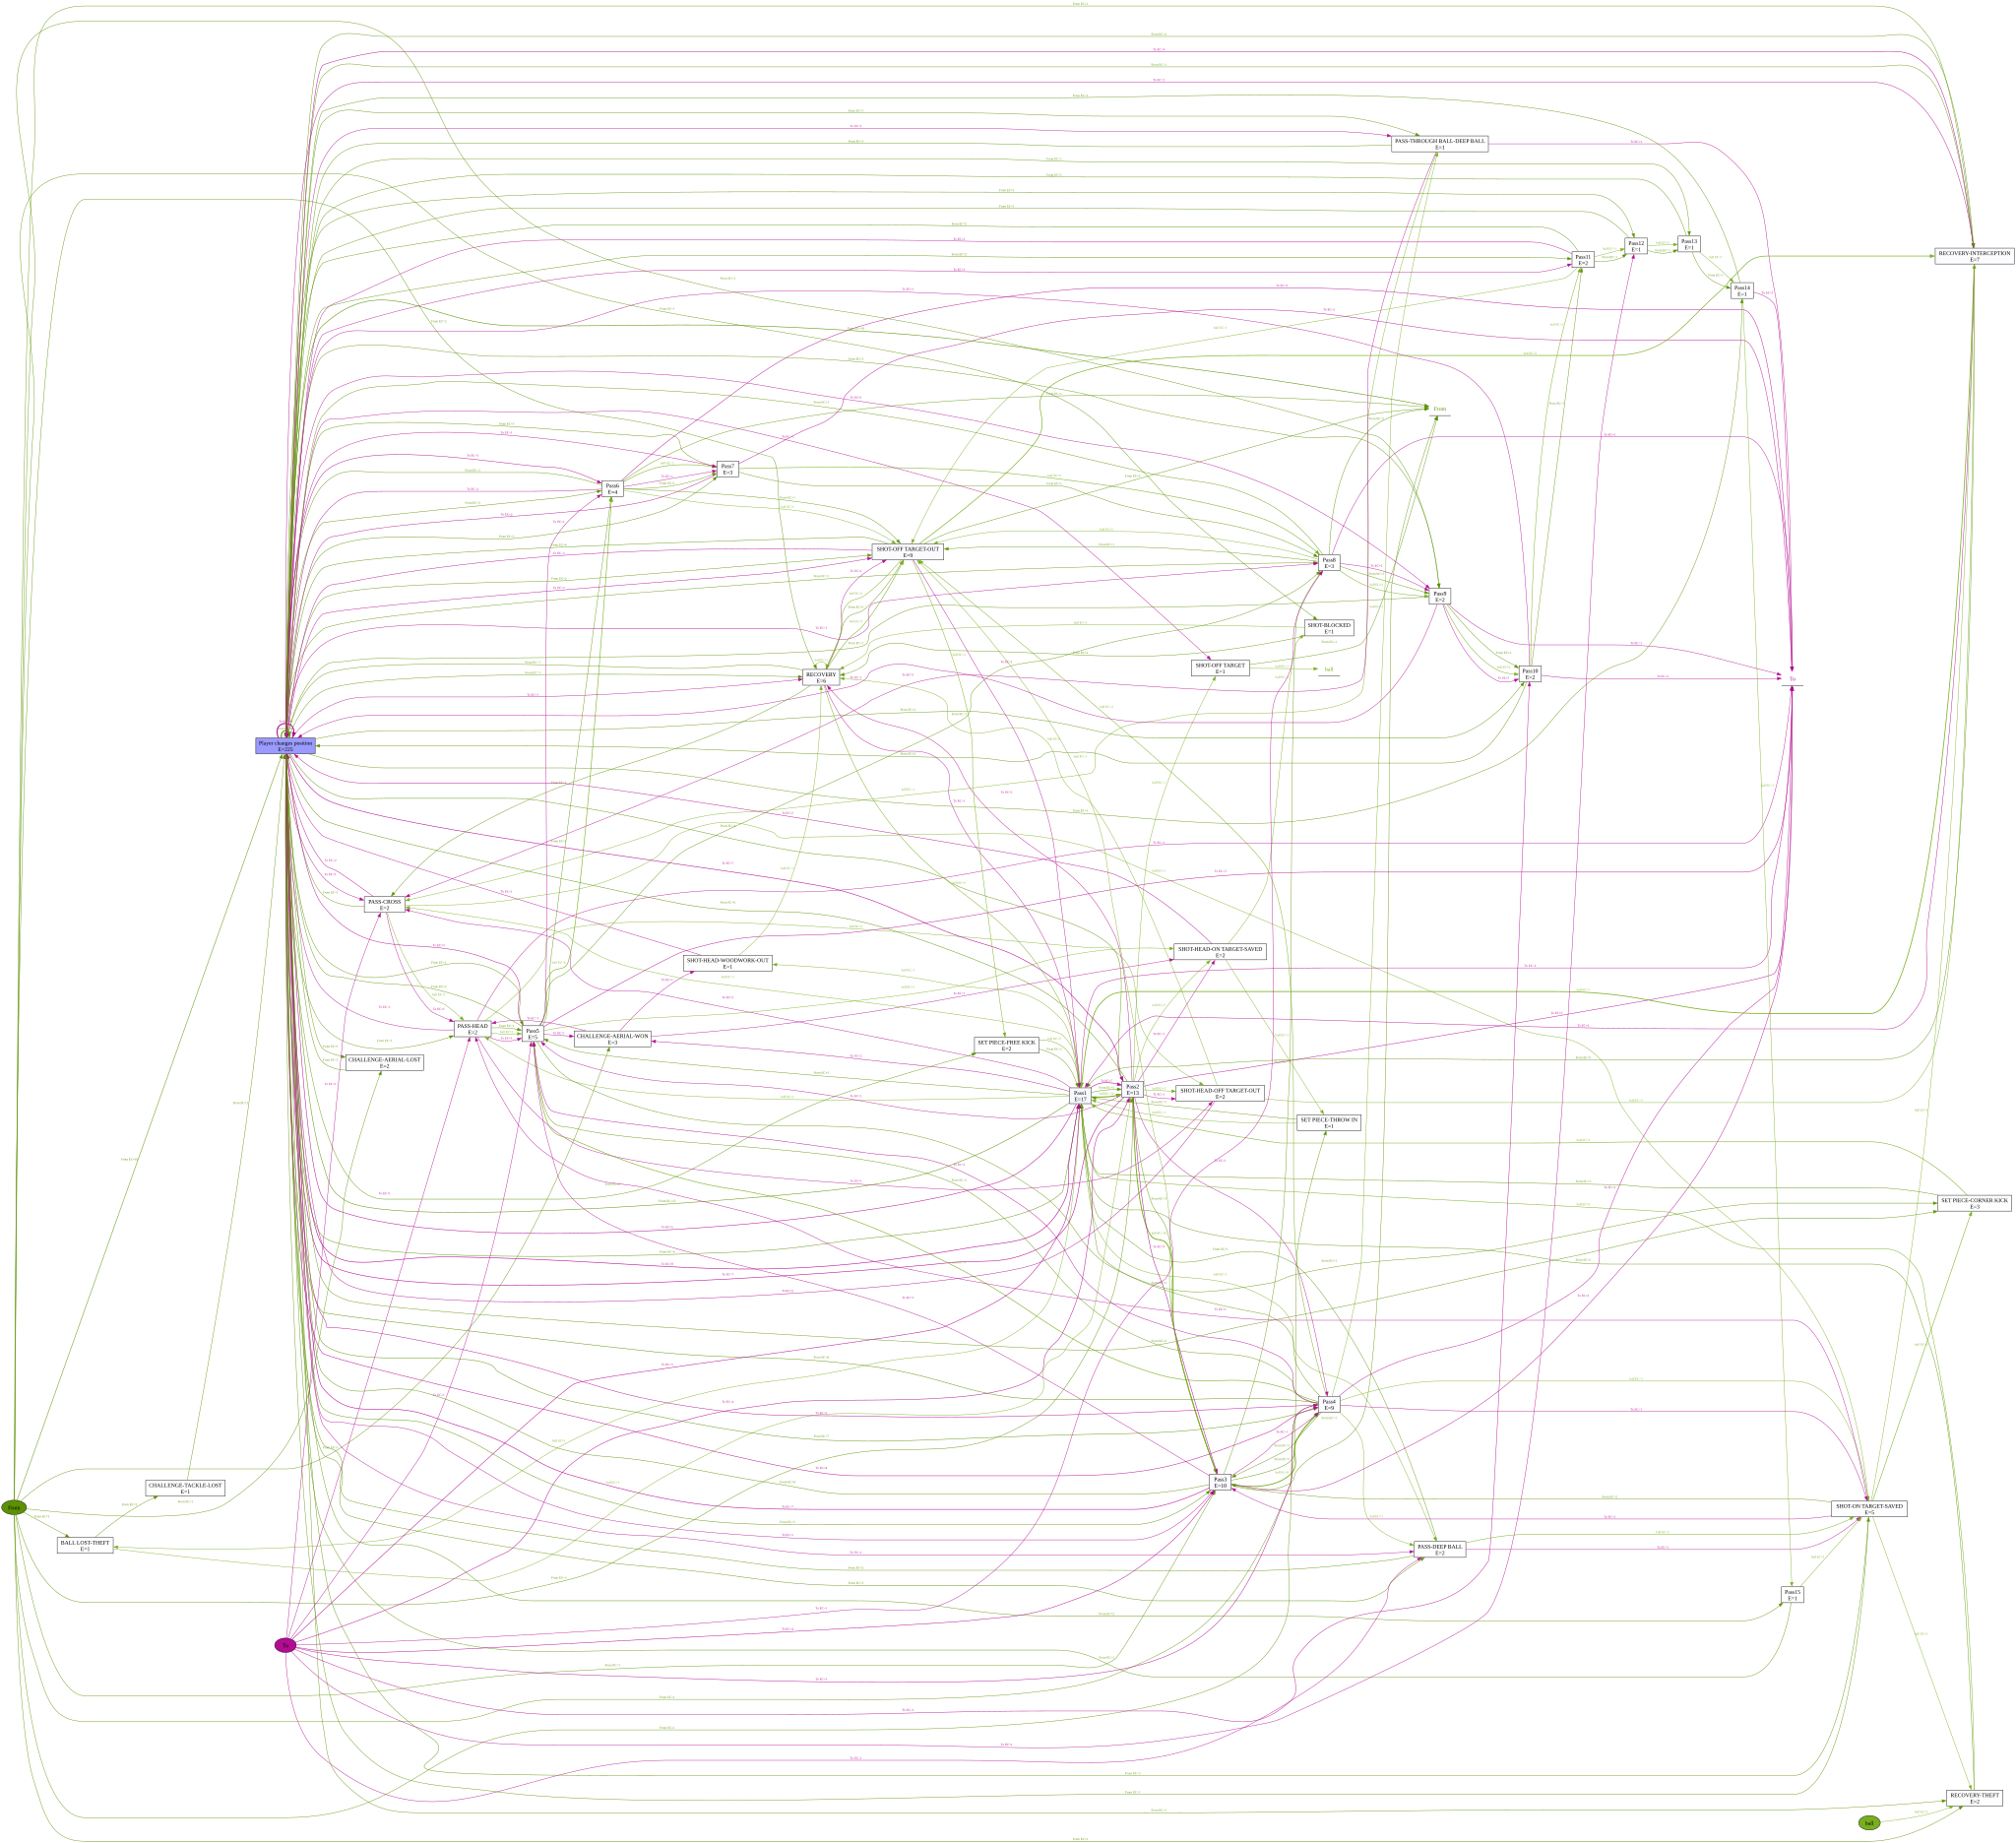

In [21]:
dfg=pm4py.ocel.discover_ocdfg(involved_player_Failed_attack_ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

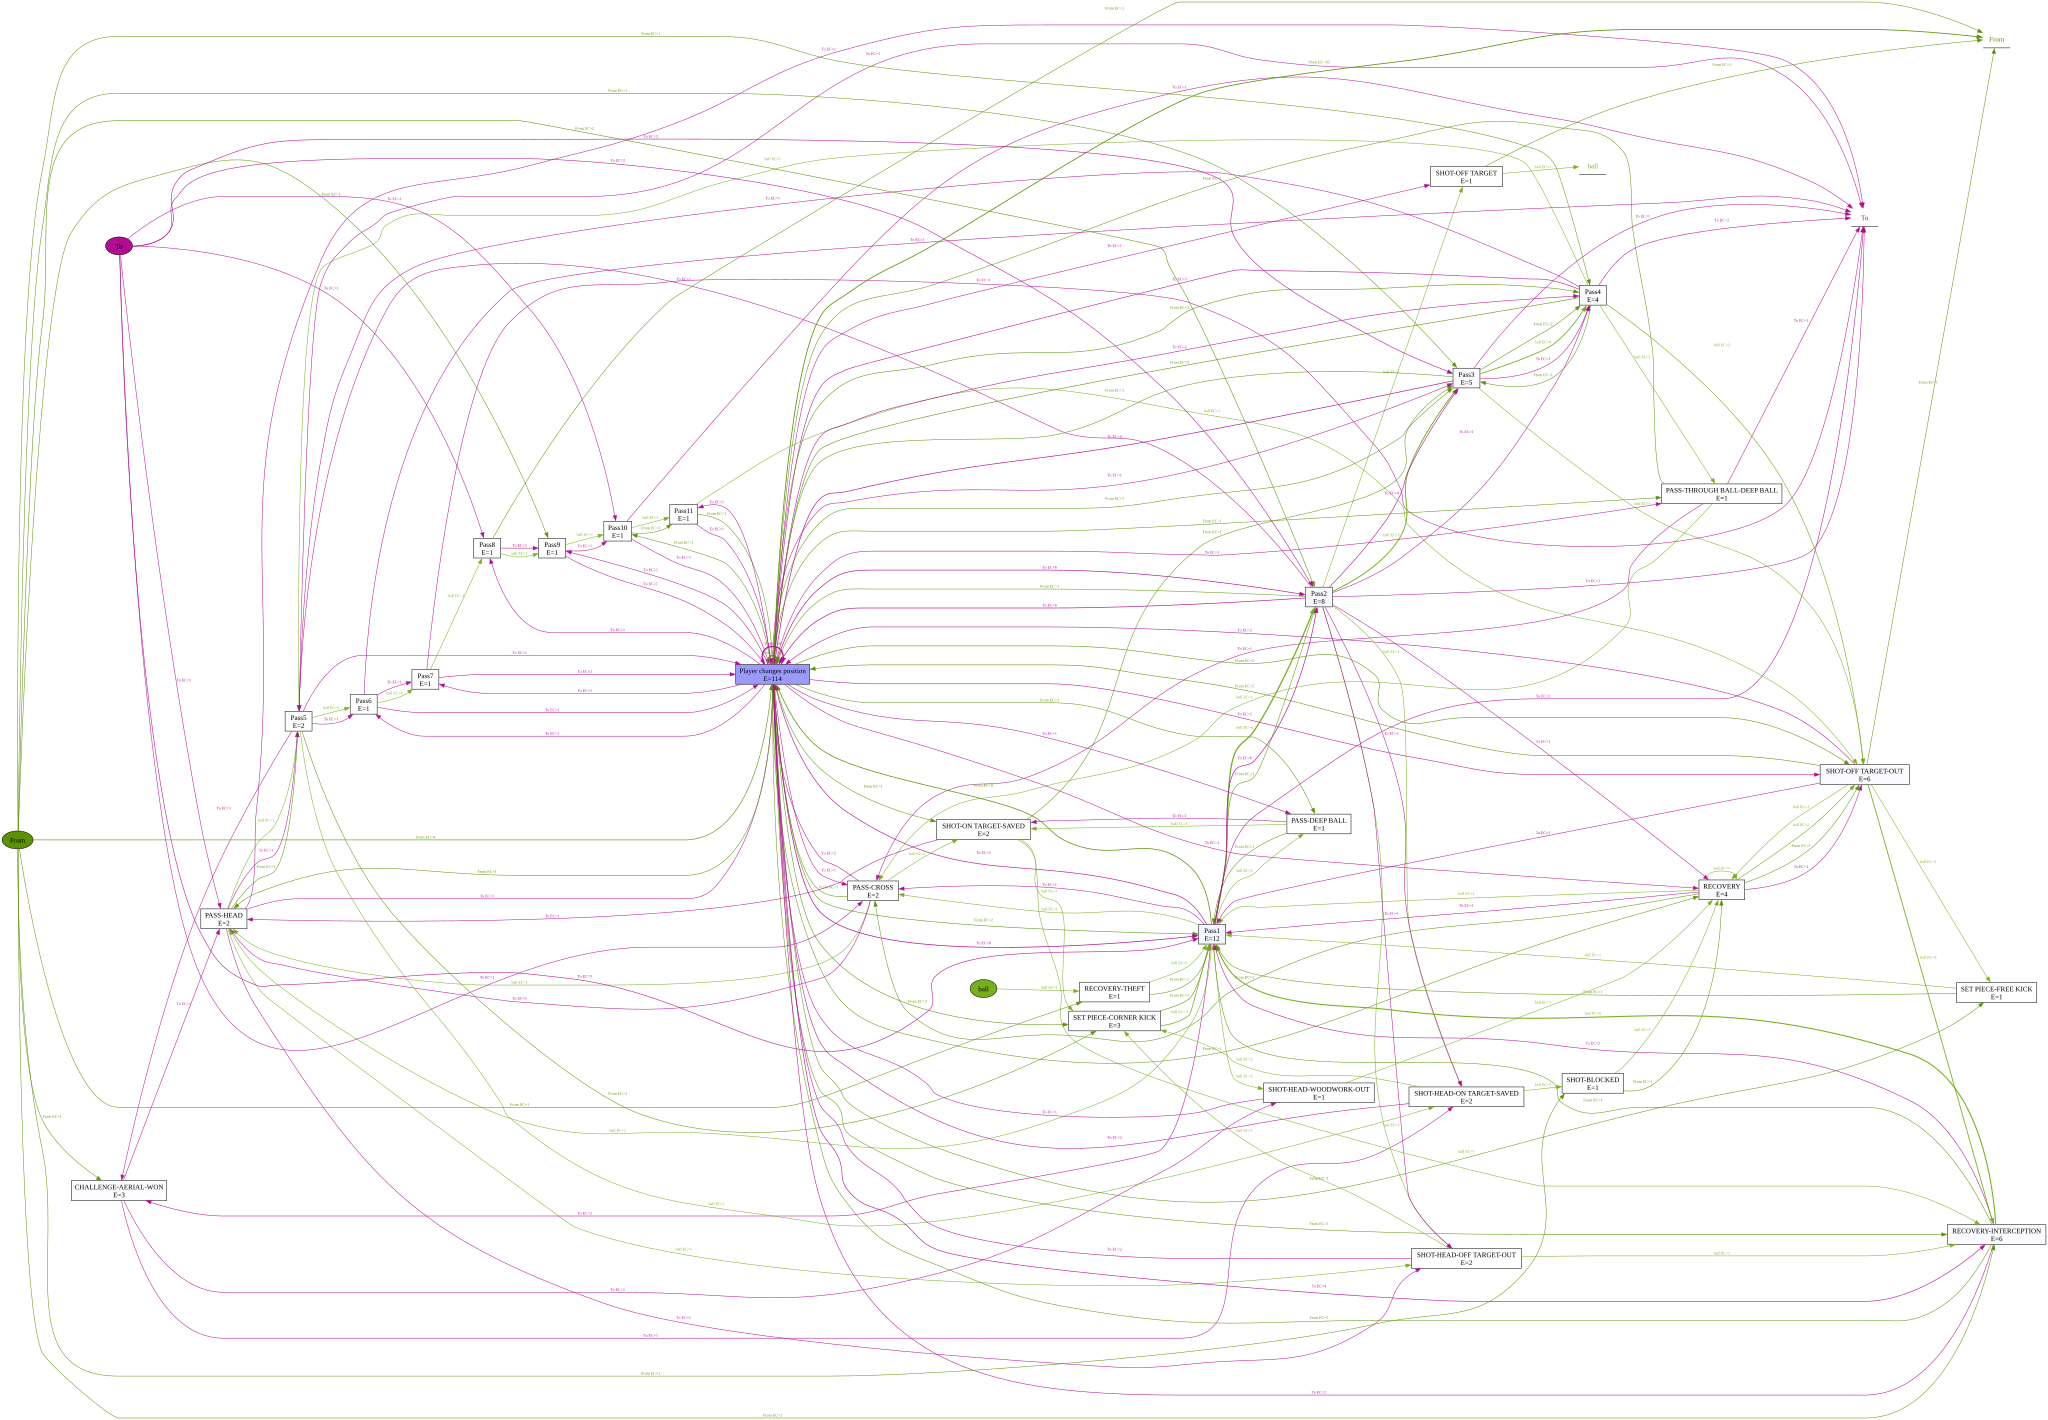

In [22]:
dfg=pm4py.ocel.discover_ocdfg(involved_player_Failed_attack_ocel_home)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

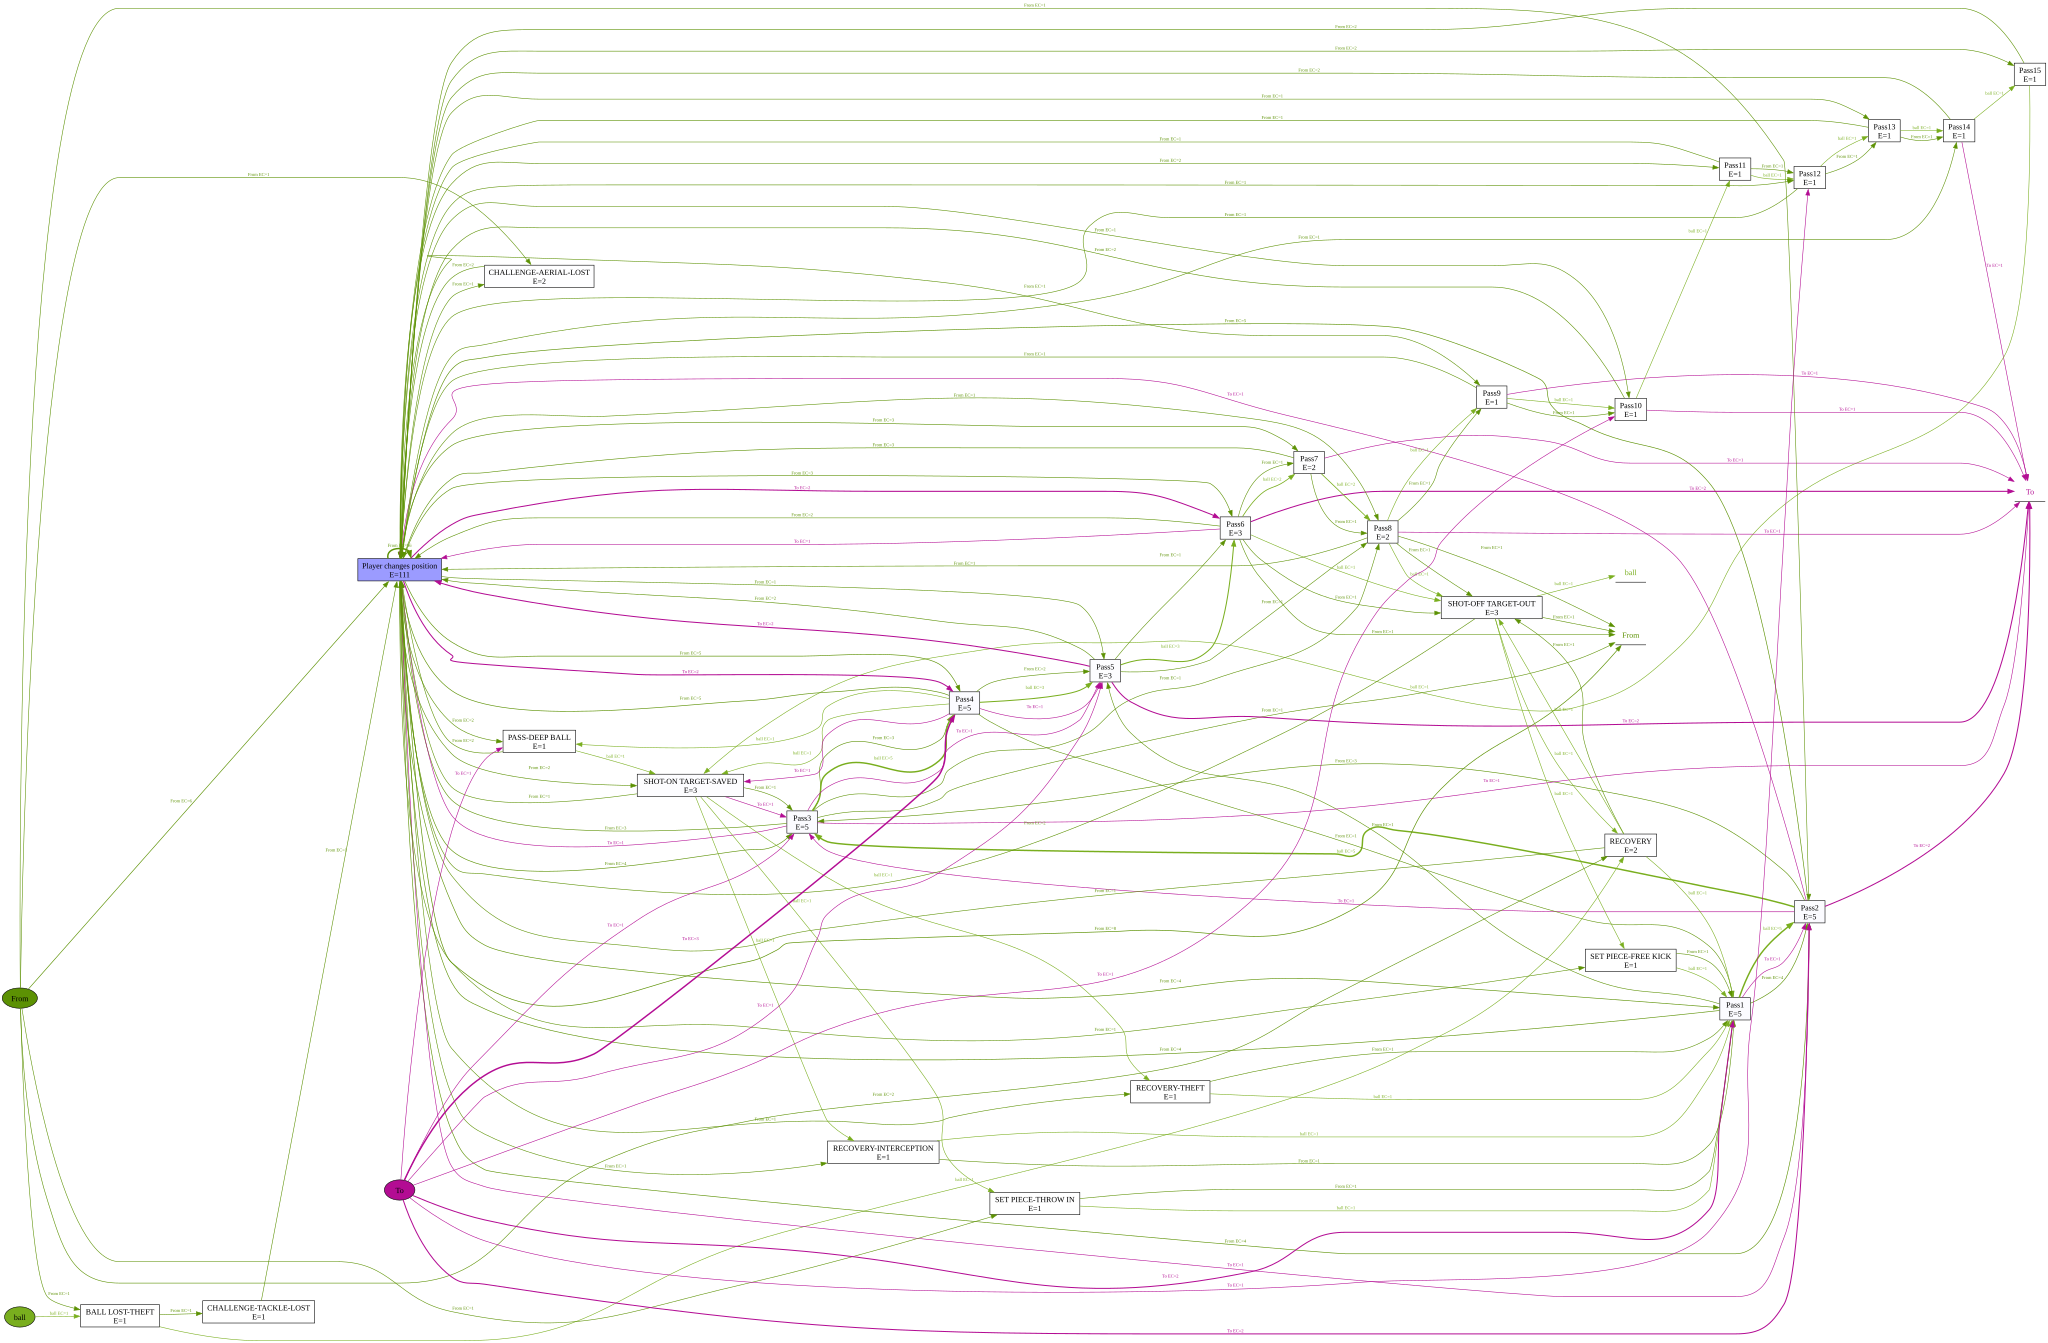

In [23]:
dfg=pm4py.ocel.discover_ocdfg(involved_player_Failed_attack_ocel_away)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

In [69]:
print('For successful shots')
result= movement_frequency_report(last_player_goal_attack_df,involved_player_goal_attack_df)

For successful shots
  case:concept:name  team last_player  position_changes  \
0             HA118  Home     Player5                 7   
1             HA121  Home    Player10                14   
2             HA133  Home     Player9                 6   
3               HA4  Home     Player9                13   

   total_position_changes  average_per_player  num_involved_players  
0                       7            7.000000                     1  
1                      27           13.500000                     2  
2                       6            6.000000                     1  
3                      40           13.333333                     3  
In this game, a total of 4 shots were made. 
The aggregated total shooter grid travel is 40 
The average shooter grid travel per shot is 10.0 
The aggregated total grid travel of all involved players is 80 
The average grid travel of all attacks involved players per shot is 20.0 
The average grid travel of all attacks involved play

In [68]:
print('For failed shots')
result= movement_frequency_report(last_player_failed_attack_df,involved_player_failed_attack_df)

For failed shots
   case:concept:name  team last_player  position_changes  \
0              AA103  Away    Player19                16   
1              AA138  Away    Player27                 5   
2              AA156  Away    Player23                 6   
3               AA16  Away    Player21                 7   
4              AA166  Away    Player28                 8   
5               AA36  Away    Player24                 7   
6              HA106  Home    Player12                 6   
7               HA11  Away    Player18                 0   
8               HA11  Home    Player10                 9   
9              HA132  Home     Player5                 0   
10             HA156  Home    Player10                 5   
11             HA160  Home    Player14                 7   
12             HA173  Home     Player9                 9   
13              HA19  Home     Player8                 7   
14              HA32  Away    Player17                 0   
15              HA32  H

In [16]:
player, movement=np.unique(ocel_df[ocel_df['concept:name']=='Player changes position']['From'], return_counts=True)
player=player[np.argsort(movement)]
movement=np.sort(movement)
print(player[0],'and',player[1],'made the least amount of travel through out the game and they are likely the goalkeeper.')
print(player[0],'belongs to the',ocel_df[ocel_df['From']==player[0]].iloc[0]['Team'],'team')
print(player[1],'belongs to the',ocel_df[ocel_df['From']==player[1]].iloc[0]['Team'],'team')

Player11 and Player25 made the least amount of travel through out the game and they are likely the goalkeeper.
Player11 belongs to the Home team
Player25 belongs to the Away team


In [ ]:
from filters_and_analysis import get_player_trajectory, fraction_time_in_goal_area

for col in tracking_data_away_df.columns:
    if col.startswith("Player"):
        _,x_trace,y_trace=get_player_trajectory(tracking_data_away_df,col)
        print(col)
        fraction_time_in_goal_area(x_trace,y_trace, 'Away')
for col in tracking_data_home_df.columns:
    if col.startswith("Player"):
        _,x_trace,y_trace=get_player_trajectory(tracking_data_home_df,col)
        print(col)
        fraction_time_in_goal_area(x_trace,y_trace, 'Home')


Player25
0.16325531357323145
Player15
0.033495165717280666
Player16
0.012764989034936485
Player17
0.014971794270581908
Player18
0.0022068052356454216
Player19
0.0033102078534681324
Player20
0.03579162241562418
Player21
0.016178640883825497
Player22
0.006089403197109085
Player23
0.006944540225921686
Player24
0.014744217480655972
Player26
0.002999875867205495
Player27
0.0006689378370550184
Player28
0.0


In [3]:
pd.set_option('display.max_columns', None)
ocel.get_extended_table()

,ocel:eid,ocel:activity,ocel:timestamp,attribute:subtype,attribute:duration,attribute:start_grid,attribute:crossed_grid,attribute:attack_game,attribute:attack_successful,attribute:home_team_score,attribute:away_team_score,attribute:end_x,attribute:end_y,attribute:start_x,attribute:start_y,attribute:travel_distance,ocel:type:Team,ocel:type:From,ocel:type:case:concept:name,ocel:type:end_grid,ocel:type:To
0,0,SET PIECE,1970-01-01 00:00:00.040,KICK OFF,-0.04,[None],False,1,False,0,0,NaN,NaN,NaN,NaN,NaN,[Away],[Player19],[AA1],NaN,NaN
1,1,Player changes position,1970-01-01 00:00:00.040,NaN,NaN,NaN,NaN,1,False,0,0,0.41094,0.72589,NaN,NaN,NaN,[Home],[Player5],[AA1],[E8],NaN
2,2,Player changes position,1970-01-01 00:00:00.040,NaN,NaN,NaN,NaN,1,False,0,0,0.52697,0.37980,NaN,NaN,NaN,[Home],[Player9],[AA1],[F4],NaN
3,3,Player changes position,1970-01-01 00:00:00.040,NaN,NaN,NaN,NaN,1,False,0,0,0.41698,0.47843,NaN,NaN,NaN,[Home],[Player6],[AA1],[E5],NaN
4,4,Player changes position,1970-01-01 00:00:00.040,NaN,NaN,NaN,NaN,1,False,0,0,0.40783,0.61525,NaN,NaN,NaN,[Away],[Player18],[AA1],[E7],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904118,904118,Player changes position,1970-01-01 01:36:40.240,NaN,NaN,NaN,NaN,355,False,4,0,NaN,NaN,NaN,NaN,NaN,[Home],[Player1],[AA175],NaN,NaN
904119,904119,Player changes position,1970-01-01 01:36:40.240,NaN,NaN,NaN,NaN,355,False,4,0,NaN,NaN,NaN,NaN,NaN,[Home],[Player6],[AA175],NaN,NaN
904120,904120,Player changes position,1970-01-01 01:36:40.240,NaN,NaN,NaN,NaN,355,False,4,0,NaN,NaN,NaN,NaN,NaN,[Away],[Player19],[AA175],NaN,NaN
904121,904121,Player changes position,1970-01-01 01:36:40.240,NaN,NaN,NaN,NaN,355,False,4,0,NaN,NaN,NaN,NaN,NaN,[Away],[Player22],[AA175],NaN,NaN


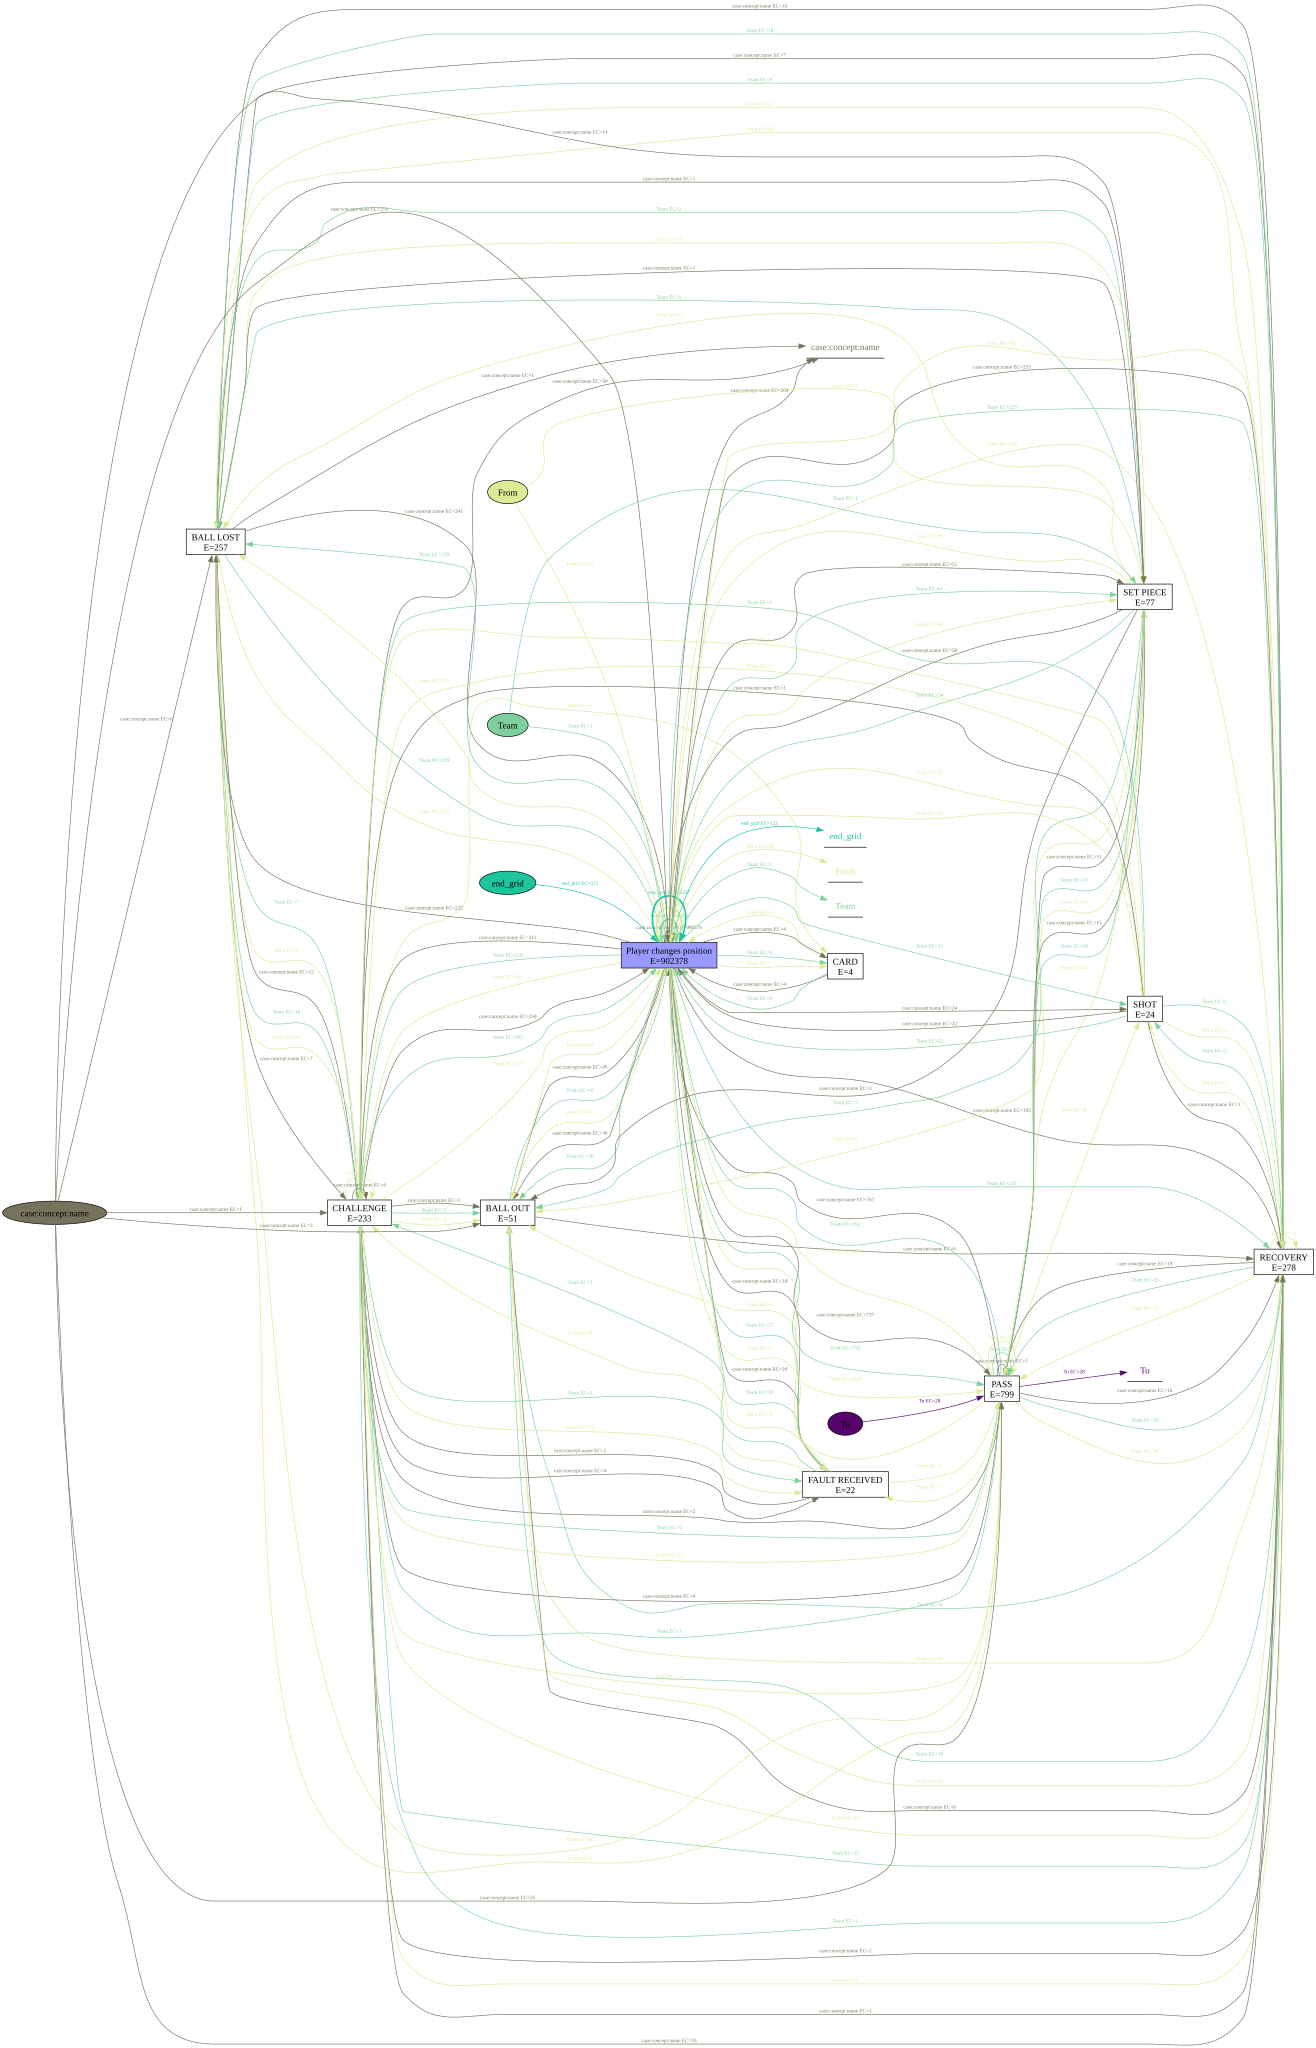

In [6]:
dfg=pm4py.ocel.discover_ocdfg(pm4py.filtering.filter_ocel_events(ocel,['Player changes position'],False))
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

In [ ]:
ocpn=pm4py.discovery.discover_oc_petri_net(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

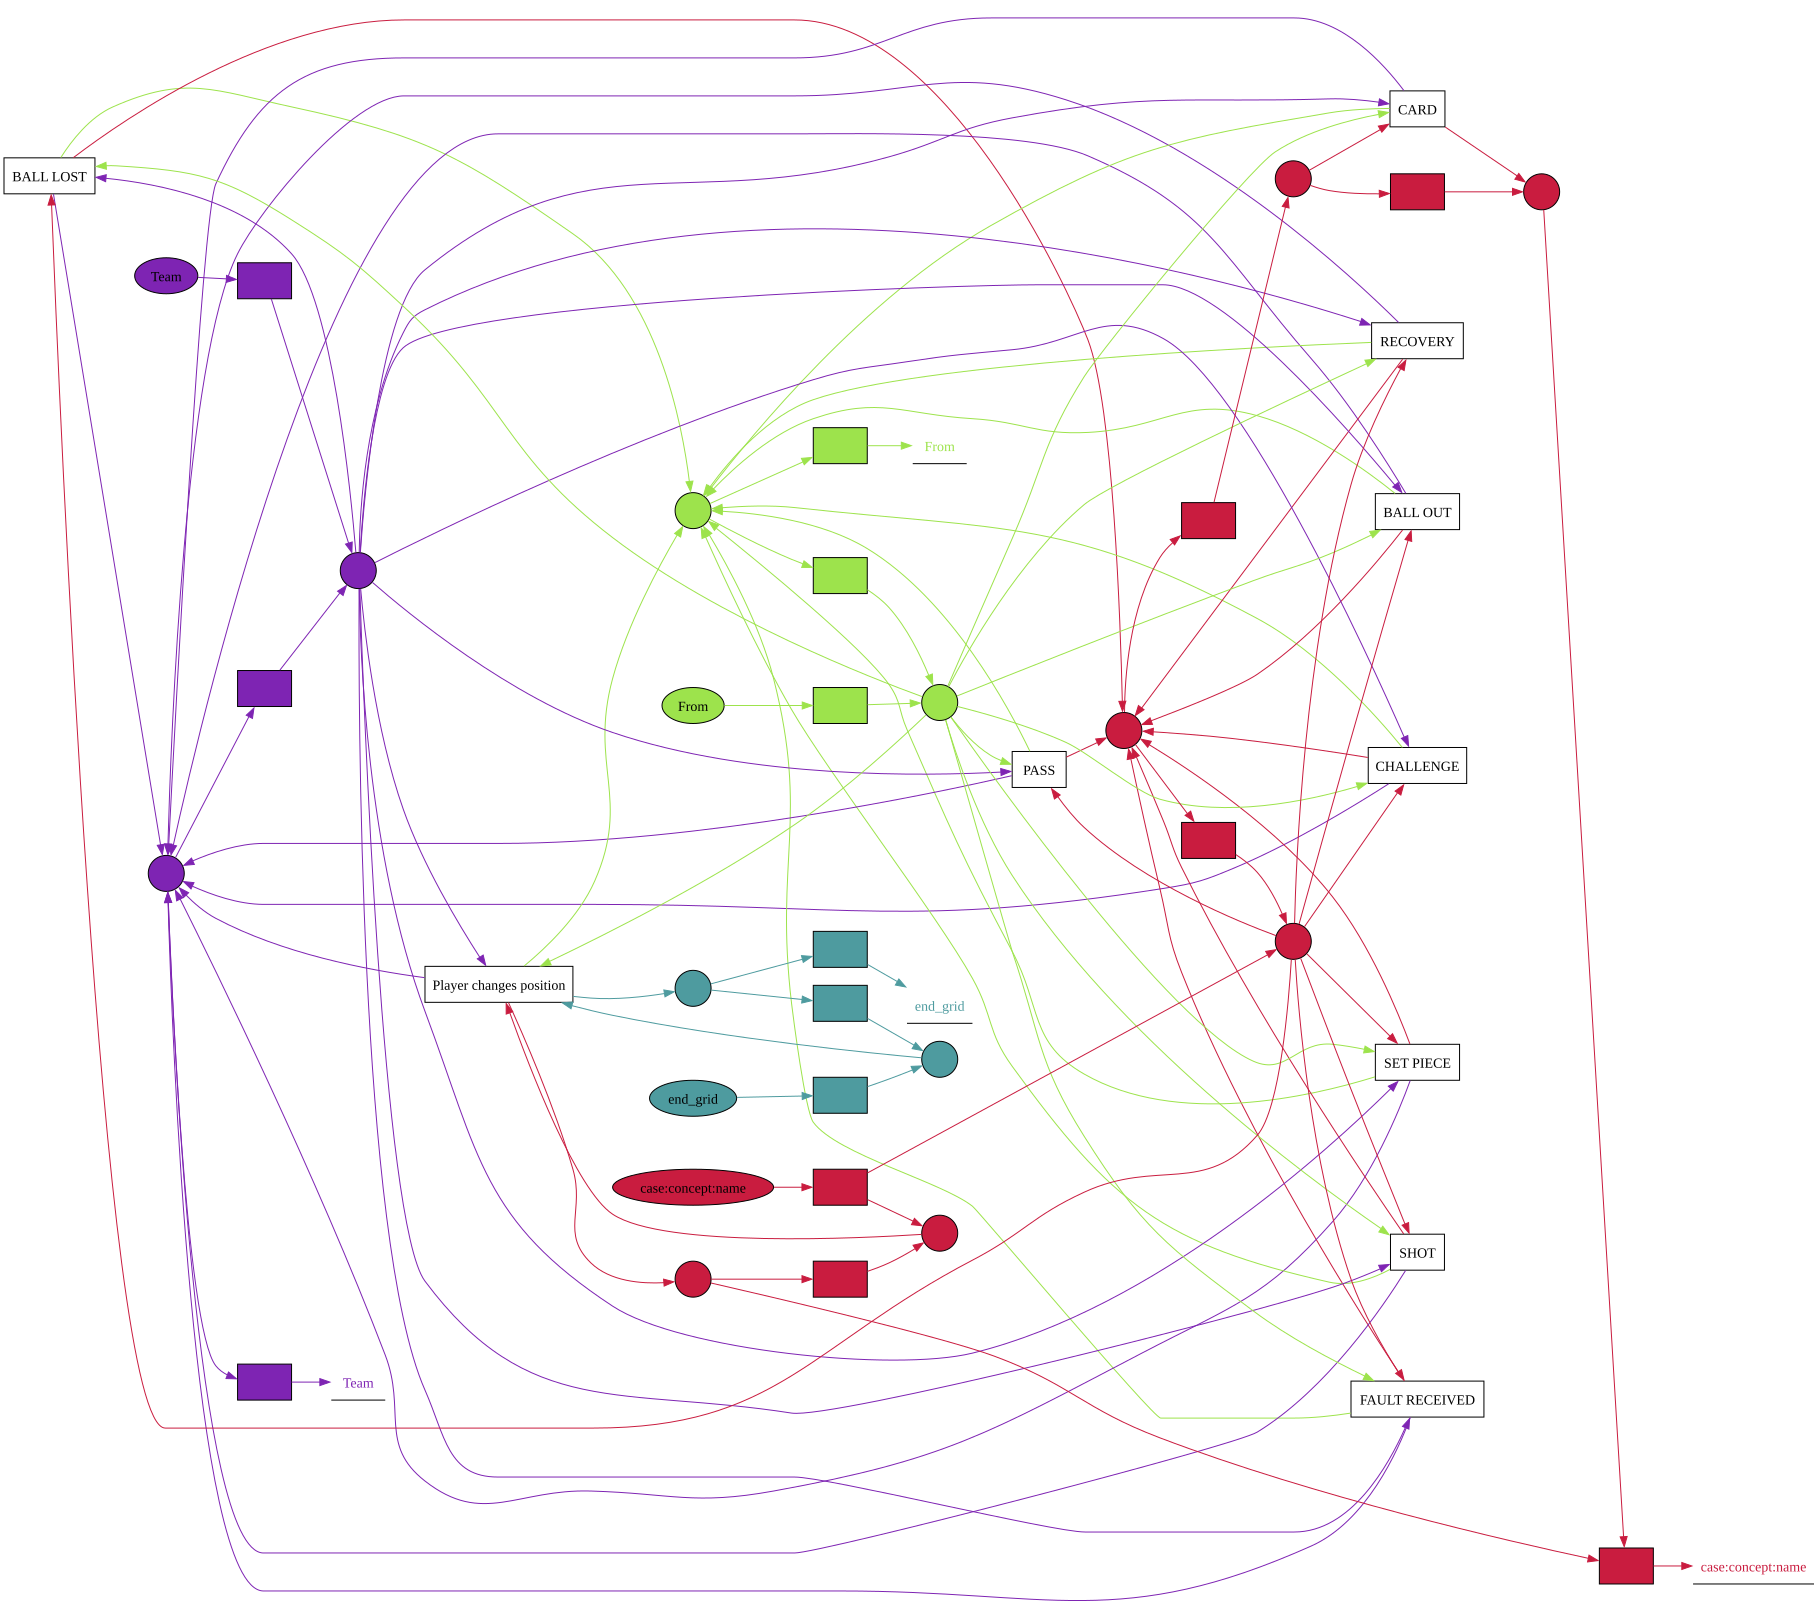

In [5]:
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

In [10]:
obj_graph = pm4py.ocel_discover_objects_graph(ocel, graph_type='object_interaction')
pm4py.visualization.ocel.objects_graph.visualizer.apply(obj_graph, parameters={"format": "svg"})

AttributeError: module 'pm4py' has no attribute 'ocel_discover_objects_graph'

In [9]:
objects_summary = pm4py.ocel_objects_summary(ocel)

In [ ]:
objects_summary['unique_activites'] = objects_summary['activities_lifecycle'].apply(lambda x: list(set(x)))
objects_summary_player=objects_summary[objects_summary['ocel:oid'].str.lower().str.startswith('player')]

In [31]:
mask_with = objects_summary_player['activities_lifecycle'].apply(lambda x: 'FAULT RECEIVED' in x)
print(objects_summary_player.loc[mask_with, 'ocel:oid'])

478     Player1
479    Player10
481    Player12
482    Player13
486    Player17
487    Player18
488    Player19
493    Player23
497    Player27
498    Player28
499     Player3
502     Player6
503     Player7
504     Player8
505     Player9
Name: ocel:oid, dtype: object


In [33]:
mask_without = objects_summary_player['activities_lifecycle'].apply(lambda x: 'FAULT RECEIVED' not in x)
print(objects_summary_player.loc[mask_without, 'ocel:oid'])

480    Player11
483    Player14
484    Player15
485    Player16
489     Player2
490    Player20
491    Player21
492    Player22
494    Player24
495    Player25
496    Player26
500     Player4
501     Player5
Name: ocel:oid, dtype: object


In [16]:
player_stats=pd.DataFrame()
player_stats['ocel:oid'] = objects_summary_player['ocel:oid']
player_stats['fault'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('FAULT RECEIVED'))
player_stats['ball_lost'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('BALL LOST'))
player_stats['card'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('CARD'))
player_stats['shot'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('SHOT'))
player_stats['recovery'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('RECOVERY'))
player_stats['set_piece'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('SET PIECE'))
player_stats['ball_out'] = objects_summary_player['activities_lifecycle'].apply(lambda x: x.count('BALL OUT'))
player_stats['away_team'] = objects_summary_player['interacting_objects'].apply(lambda x: 'Away' in x)
player_stats['home_team'] = objects_summary_player['interacting_objects'].apply(lambda x: 'Home' in x)
player_stats.sort_values(by='home_team', inplace=True)
player_stats

,ocel:oid,fault,ball_lost,card,shot,recovery,set_piece,ball_out,away_team,home_team
491,Player21,0,15,0,1,8,6,1,True,False
494,Player24,0,2,0,1,0,0,0,True,False
493,Player23,1,4,0,1,4,1,1,True,False
492,Player22,0,11,0,0,12,8,5,True,False
497,Player27,1,2,0,1,4,0,1,True,False
490,Player20,0,4,0,0,10,1,3,True,False
498,Player28,2,2,0,1,1,0,1,True,False
488,Player19,1,23,0,1,14,7,3,True,False
495,Player25,0,9,0,0,20,3,3,True,False
487,Player18,1,15,0,0,9,2,2,True,False


In [ ]:
#took super long not sure if it works
pm4py.ocel.ocel_temporal_summary(ocel)

,ocel:timestamp,ocel:activity,ocel:oid
0,1970-01-01 00:00:00.040,"[SET PIECE, SET PIECE, SET PIECE, SET PIECE, P...","[Away, Player19, AA1, ball_1, Away, Player19, ..."
1,1970-01-01 00:00:00.120,"[PASS Received, PASS Received, PASS Received, ...","[Away, Player21, AA1, D2, ball_1, Away, Player..."
2,1970-01-01 00:00:00.240,"[Player changes position, Player changes posit...","[Away, Player22, AA1, C4]"
3,1970-01-01 00:00:00.560,"[Player changes position, Player changes posit...","[Away, Player17, AA1, D4]"
4,1970-01-01 00:00:00.680,"[PASS Received, PASS Received, PASS Received, ...","[Away, Player15, AA1, D1, ball_1]"
5,1970-01-01 00:00:00.760,"[Player changes position, Player changes posit...","[Away, Player17, AA1, D3]"
6,1970-01-01 00:00:00.920,"[Player changes position, Player changes posit...","[Away, Player16, AA1, D2]"
7,1970-01-01 00:00:00.960,"[Player changes position, Player changes posit...","[Home, Player2, AA1, B2]"
8,1970-01-01 00:00:01.800,"[PASS Out, PASS Out, PASS Out, PASS Out, PASS ...","[Away, Player15, AA1, C2, ball_1]"
9,1970-01-01 00:00:02.080,"[Player changes position, Player changes posit...","[Away, Player24, AA1, B2]"


In [23]:
pm4py.statistics.ocel.act_utils.find_associations_from_ocel(ocel, {'EVENT_ACTIVIT':'SHOT'})

{'BALL LOST': [('2216', 'Away'),
  ('2216', 'Player17'),
  ('2216', 'AA1'),
  ('2421', 'Home'),
  ('2421', 'Player2'),
  ('2421', 'HA1'),
  ('2889', 'Away'),
  ('2889', 'Player16'),
  ('2889', 'AA2'),
  ('3643', 'Home'),
  ('3643', 'Player10'),
  ('3643', 'HA2'),
  ('7052', 'Away'),
  ('7052', 'Player17'),
  ('7052', 'AA3'),
  ('8748', 'Home'),
  ('8748', 'Player8'),
  ('8748', 'HA3'),
  ('27779', 'Home'),
  ('27779', 'Player10'),
  ('27779', 'HA5'),
  ('28053', 'Away'),
  ('28053', 'Player19'),
  ('28053', 'AA6'),
  ('28885', 'Home'),
  ('28885', 'Player1'),
  ('28885', 'HA6'),
  ('29441', 'Away'),
  ('29441', 'Player17'),
  ('29441', 'AA7'),
  ('31713', 'Away'),
  ('31713', 'Player19'),
  ('31713', 'AA8'),
  ('32486', 'Home'),
  ('32486', 'Player1'),
  ('32486', 'HA8'),
  ('32653', 'Away'),
  ('32653', 'Player19'),
  ('32653', 'AA9'),
  ('33196', 'Home'),
  ('33196', 'Player1'),
  ('33196', 'HA9'),
  ('34407', 'Away'),
  ('34407', 'Player18'),
  ('34407', 'AA10'),
  ('34502', 'Home')

In [27]:
ocel_logs_by_object_type

[Object-Centric Event Log (number of events: 904123, number of objects: 506, number of activities: 10, number of object types: 4, events-objects relationships: 2745516)
 Activities occurrences: Counter({'Player changes position': 902378, 'PASS': 799, 'RECOVERY': 278, 'BALL LOST': 257, 'CHALLENGE': 233, 'SET PIECE': 77, 'BALL OUT': 51, 'SHOT': 24, 'FAULT RECEIVED': 22, 'CARD': 4})
 Object types occurrences (number of objects): Counter({'case:concept:name': 355, 'end_grid': 121, 'From': 28, 'Team': 2})
 Unique activities per object type: Counter({'From': 10, 'Team': 10, 'case:concept:name': 10, 'To': 1, 'end_grid': 1})
 Please use <THIS>.get_extended_table() to get a dataframe representation of the events related to the objects.]

In [32]:
from pm4py.algo.transformation.ocel.graphs import object_interaction_graph
obj_graph = object_interaction_graph.apply(ocel)#, {'graph_type':'object_interaction'})
obj_graph
#pm4py.visualization.ocel.objects_graph.visualizer.apply(obj_graph, parameters={"format": "svg"})

{('AA40', 'Player25'),
 ('HA47', 'Player23'),
 ('AA124', 'Player7'),
 ('D5', 'Player7'),
 ('G8', 'HA92'),
 ('D6', 'HA111'),
 ('AA162', 'Player9'),
 ('AA98', 'I4'),
 ('AA21', 'I5'),
 ('HA118', 'Player16'),
 ('H5', 'Player24'),
 ('AA101', 'I9'),
 ('AA98', 'Player14'),
 ('AA51', 'E6'),
 ('AA104', 'B7'),
 ('AA155', 'Player2'),
 ('H6', 'Player16'),
 ('G3', 'Player4'),
 ('HA32', 'Player3'),
 ('AA21', 'J1'),
 ('C3', 'Player23'),
 ('AA114', 'Player15'),
 ('HA107', 'Player12'),
 ('HA129', 'Player2'),
 ('Player17', 'Player26'),
 ('HA115', 'Player14'),
 ('Player17', 'Player19'),
 ('HA54', 'Player15'),
 ('C7', 'HA132'),
 ('HA152', 'Player7'),
 ('AA99', 'H1'),
 ('AA111', 'Player27'),
 ('HA49', 'Player25'),
 ('C8', 'Home'),
 ('HA81', 'Player22'),
 ('H5', 'HA32'),
 ('G10', 'Player12'),
 ('AA63', 'G3'),
 ('C5', 'Player6'),
 ('AA130', 'Player16'),
 ('AA19', 'I1'),
 ('D6', 'HA119'),
 ('I10', 'Player22'),
 ('AA44', 'Away'),
 ('E4', 'HA115'),
 ('HA111', 'Player25'),
 ('AA162', 'G1'),
 ('HA67', 'Player8'),

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(obj_graph)  # or use kamada_kawai_layout, shell_layout, etc.
nx.draw(obj_graph, pos, with_labels=True, node_size=5, font_size=10, arrows=True)
edge_labels = nx.get_edge_attributes(obj_graph, 'weight')  # or another attribute if used
nx.draw_networkx_edge_labels(obj_graph, pos, edge_labels=edge_labels)
plt.title("Object Interaction Graph")
plt.show()


In [ ]:
pm4py.algo.transformation.ocel.features.objects.object_degree_centrality.apply(ocel)